# Notebook 01: EDA and Data Cleaning

**Track:** `eda_20260429`
**Type:** Feature
**Status:** Active

## 1. How to run
To execute this notebook, choose **Runtime > Run all** (or **Restart and run all**). Ensure that your Google Drive is accessible, as it contains the raw `IEEE-CIS Fraud Detection` CSV files in the same directory as this notebook. The notebook will automatically downcast data for memory efficiency, but a standard Colab runtime (12 GB RAM) is sufficient.

## 2. Setup

In [1]:
!pip install -q pyarrow fastparquet matplotlib seaborn missingno pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 49.4 MB/s eta 0:00:00


## 3. Imports

In [2]:
import gc
import json
import os
import platform
import random
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno

# Standardize visual outputs
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings("ignore")

## 4. Reproducibility

In [3]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(SEED)

print(f"Python version: {sys.version}")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"System: {platform.system()} {platform.release()}")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas version: 2.2.2
Numpy version: 2.0.2
System: Linux 6.6.113+


## 5. Paths & I/O Contract

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Base directory assuming the notebook is in the specific Drive folder
# Update BASE_DIR if your notebook is located in a specific subfolder inside MyDrive
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/GL-MS-CapStone'

PATHS = {
    "raw_data": os.path.join(BASE_DIR, "data", "raw"),
    "processed_data": os.path.join(BASE_DIR, "data", "processed"),
    "figures": os.path.join(BASE_DIR, "outputs", "explanations", "figures"),
    "metrics": os.path.join(BASE_DIR, "outputs", "metrics")
}

# Idempotent path creation
for path_key, path_val in PATHS.items():
    if path_key != "raw_data":
        os.makedirs(path_val, exist_ok=True)

print("Paths configured:", json.dumps(PATHS, indent=2))

Mounted at /content/drive
Paths configured: {
  "raw_data": "/content/drive/MyDrive/Colab Notebooks/GL-MS-CapStone/data/raw",
  "processed_data": "/content/drive/MyDrive/Colab Notebooks/GL-MS-CapStone/data/processed",
  "figures": "/content/drive/MyDrive/Colab Notebooks/GL-MS-CapStone/outputs/explanations/figures",
  "metrics": "/content/drive/MyDrive/Colab Notebooks/GL-MS-CapStone/outputs/metrics"
}


## 6. Data Load
Loading the `train_transaction.csv`, `train_identity.csv`, `test_transaction.csv`, and `test_identity.csv` files.

In [5]:
def load_data():
    print("Loading data...")
    start_time = time.time()

    # Modify file names if they differ in your drive
    train_trans_path = os.path.join(PATHS['raw_data'], 'train_transaction.csv')
    train_id_path = os.path.join(PATHS['raw_data'], 'train_identity.csv')
    test_trans_path = os.path.join(PATHS['raw_data'], 'test_transaction.csv')
    test_id_path = os.path.join(PATHS['raw_data'], 'test_identity.csv')

    # Load full datasets
    train_transaction = pd.read_csv(train_trans_path)
    train_identity = pd.read_csv(train_id_path)
    test_transaction = pd.read_csv(test_trans_path)
    test_identity = pd.read_csv(test_id_path)

    print(f"Loaded in {time.time() - start_time:.2f} seconds.")
    print(f"Train Transaction: {train_transaction.shape}")
    print(f"Train Identity: {train_identity.shape}")
    print(f"Test Transaction: {test_transaction.shape}")
    print(f"Test Identity: {test_identity.shape}")

    return train_transaction, train_identity, test_transaction, test_identity

train_transaction, train_identity, test_transaction, test_identity = load_data()

Loading data...
Loaded in 46.91 seconds.
Train Transaction: (590540, 394)
Train Identity: (144233, 41)
Test Transaction: (506691, 393)
Test Identity: (141907, 41)


## 7. Joins & Schema Validation
Joining the transaction and identity frames on `TransactionID` (`left` join). We assert that `TransactionID` is unique before the join and that the join does not inflate the row count.

In [6]:
# FR-1: Joins & schema validation
print("Validating pre-join schemas...")
assert train_transaction['TransactionID'].is_unique, "Train TransactionID is not unique!"
assert test_transaction['TransactionID'].is_unique, "Test TransactionID is not unique!"

train_len = len(train_transaction)
test_len = len(test_transaction)

train_merged = train_transaction.merge(train_identity, on='TransactionID', how='left')
test_merged = test_transaction.merge(test_identity, on='TransactionID', how='left')

assert len(train_merged) == train_len, "Train join inflated rows!"
assert len(test_merged) == test_len, "Test join inflated rows!"

print(f"Train merged shape: {train_merged.shape}")
print(f"Test merged shape: {test_merged.shape}")

# Free memory
del train_transaction, train_identity, test_transaction, test_identity
gc.collect()

Validating pre-join schemas...
Train merged shape: (590540, 434)
Test merged shape: (506691, 433)


4

## 8. Cleaning
Applying the documented cleaning rules:
- Drop columns with > 90% missingness in the training frame from both datasets.
- Drop rows with negative `TransactionAmt`.
- Fill missing numeric values with the XGBoost-friendly sentinel `-999`.
- Fill missing categorical values with the literal token `"missing"`.
- Downcast `float64` -> `float32` and `int64` -> `int32` for memory optimization.

In [7]:
import gc
eda_summary = {}

# 1. High-missingness drop (> 90% in training frame)
missing_rates = train_merged.isna().mean()
drop_cols = missing_rates[missing_rates > 0.9].index.tolist()
eda_summary['dropped_columns'] = drop_cols
print(f"Dropping {len(drop_cols)} columns with >90% missingness.")
display(pd.DataFrame({'Column': drop_cols, 'Missing_Rate': missing_rates[drop_cols].values}).head())

train_merged.drop(columns=drop_cols, inplace=True)
test_merged.drop(columns=drop_cols, inplace=True, errors='ignore')
gc.collect()

# 2. Impossible-value trim
pre_trim_len = len(train_merged)
train_merged = train_merged[train_merged['TransactionAmt'] >= 0]
eda_summary['dropped_negative_amt_rows'] = pre_trim_len - len(train_merged)
print(f"Dropped {eda_summary['dropped_negative_amt_rows']} rows with negative TransactionAmt.")
gc.collect()

# 3. Sentinel Imputation (in-place to save memory)
num_cols = train_merged.select_dtypes(include=[np.number]).columns.drop(['isFraud'], errors='ignore')
cat_cols = train_merged.select_dtypes(exclude=[np.number]).columns

for col in num_cols:
    train_merged[col].fillna(-999, inplace=True)
    if col in test_merged.columns:
        test_merged[col].fillna(-999, inplace=True)

for col in cat_cols:
    train_merged[col].fillna("missing", inplace=True)
    if col in test_merged.columns:
        test_merged[col].fillna("missing", inplace=True)
gc.collect()

# 4. dtype optimization (downcast in-place)
def downcast_dtypes(df):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        elif df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')
    end_mem = df.memory_usage().sum() / 1024**2
    return start_mem, end_mem

tr_start, tr_end = downcast_dtypes(train_merged)
te_start, te_end = downcast_dtypes(test_merged)

eda_summary['downcast_log'] = {
    'train_start_mb': tr_start, 'train_end_mb': tr_end,
    'test_start_mb': te_start, 'test_end_mb': te_end
}
downcast_df = pd.DataFrame([
    {"Dataset": "Train", "Memory Before (MB)": tr_start, "Memory After (MB)": tr_end},
    {"Dataset": "Test", "Memory Before (MB)": te_start, "Memory After (MB)": te_end}
])
print("\nDowncast Memory Usage:")
display(downcast_df)

Dropping 12 columns with >90% missingness.


,Column,Missing_Rate
0,dist2,0.936284
1,D7,0.934099
2,id_07,0.991271
3,id_08,0.991271
4,id_18,0.923607


Dropped 0 rows with negative TransactionAmt.

Downcast Memory Usage:


,Dataset,Memory Before (MB),Memory After (MB)
0,Train,1901.305363,1015.981953
1,Test,1666.136456,892.987347


## 9. Light Feature Engineering
We derive a few base features for downstream EDA and modeling:
- `amount_log`: log1p of `TransactionAmt`.
- `txn_hour`: Cyclic hour derived from `TransactionDT`.
- `txn_day_of_week`: Derived from `TransactionDT`. *Caveat: The absolute day-of-week is unknown because `TransactionDT` is a relative timedelta, so we use `reference_offset = 0` to preserve the cyclic pattern.*
- `card_txn_count`: Frequency of `card1` mapped from the training frame.

In [8]:
for df in [train_merged, test_merged]:
    df['amount_log'] = np.log1p(df['TransactionAmt'])
    df['txn_hour'] = (df['TransactionDT'] // 3600) % 24
    df['txn_day_of_week'] = (df['TransactionDT'] // 86400) % 7

# card_txn_count computed on training frame, mapped to test
card1_counts = train_merged['card1'].value_counts().to_dict()
train_merged['card_txn_count'] = train_merged['card1'].map(card1_counts)
test_merged['card_txn_count'] = test_merged['card1'].map(card1_counts).fillna(0).astype('int32')

print("Feature engineering complete.")
print(f"Train final shape: {train_merged.shape}")
print(f"Test final shape: {test_merged.shape}")

Feature engineering complete.
Train final shape: (590540, 426)
Test final shape: (506691, 435)


## 10. EDA — Insight Buckets

### A. Class Imbalance & Fraud Prevalence

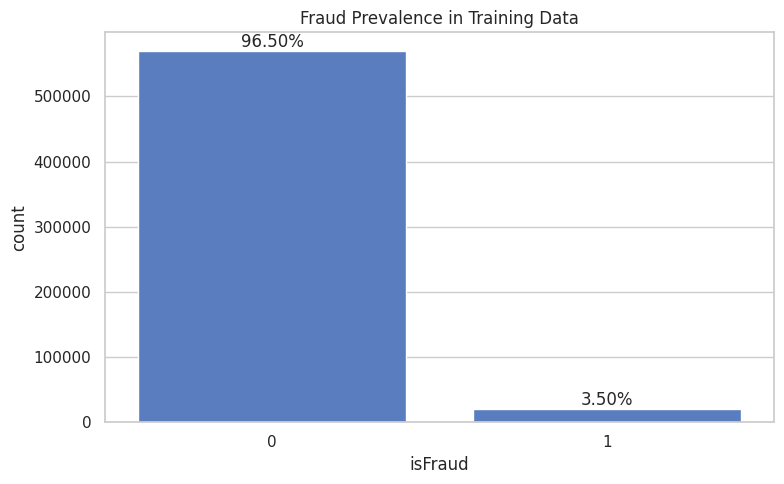

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=train_merged, x='isFraud', ax=ax)
ax.set_title('Fraud Prevalence in Training Data')

total = len(train_merged)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.2f}%'
    ax.annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
fig_path = os.path.join(PATHS['figures'], 'figure_01_class_imbalance.png')
plt.savefig(fig_path, dpi=300)
plt.show()

**Insight:** The dataset is highly imbalanced, with fraud representing roughly 3.5% of the total transactions, which motivates the need for careful sampling strategies or specialized loss functions in the downstream modeling track.

### B. Missing-Data Structure
Because we already replaced `NaN` with `-999` and `"missing"` in the cleaning step, we will identify missingness based on these sentinels.

Top 15 Columns by Missing Rate:


,Column,Missing_Rate
0,D13,0.895093
1,D14,0.894695
2,D12,0.890410
3,id_03,0.887689
4,id_04,0.887689
5,D6,0.876068
6,id_33,0.875895
7,id_09,0.873123
8,D8,0.873123
9,D9,0.873123


Average missingness in V* block (339 cols): 43.04%
Average missingness in id_* block (28 cols): 79.95%


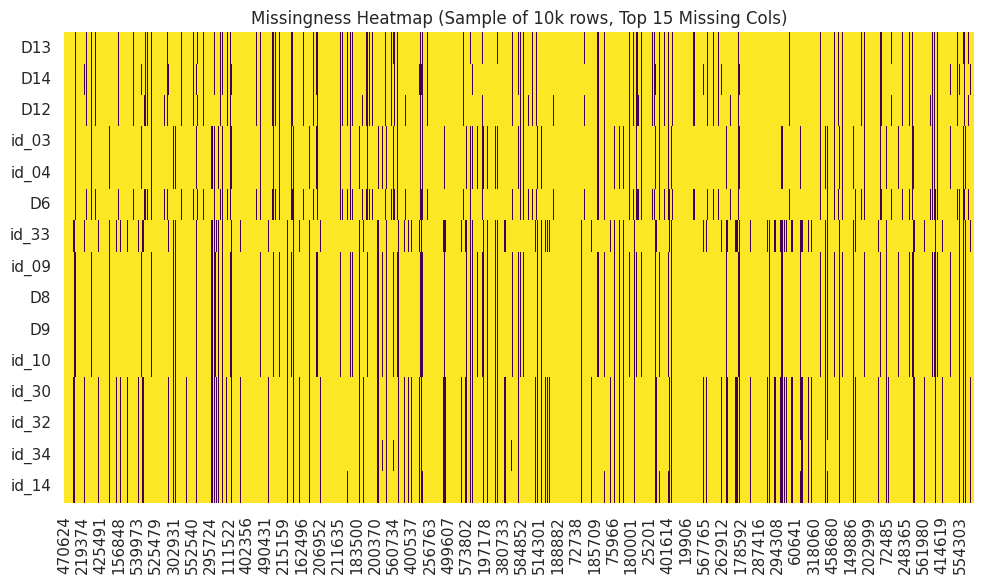

In [10]:
# Calculate missingness based on our sentinels
is_missing = (train_merged == -999) | (train_merged == "missing")
missing_rates = is_missing.mean().sort_values(ascending=False)
top_missing = missing_rates[missing_rates > 0].head(15)

print("Top 15 Columns by Missing Rate:")
display(pd.DataFrame({'Column': top_missing.index, 'Missing_Rate': top_missing.values}))

# Group coverage
v_cols = [c for c in train_merged.columns if c.startswith('V')]
id_cols = [c for c in train_merged.columns if c.startswith('id_')]

print(f"Average missingness in V* block ({len(v_cols)} cols): {is_missing[v_cols].mean().mean():.2%}")
print(f"Average missingness in id_* block ({len(id_cols)} cols): {is_missing[id_cols].mean().mean():.2%}")

# Heatmap of top 15 missing columns (sample for performance)
plt.figure(figsize=(10, 6))
sns.heatmap(is_missing[top_missing.index].sample(10000, random_state=SEED).T,
            cbar=False, cmap='viridis')
plt.title('Missingness Heatmap (Sample of 10k rows, Top 15 Missing Cols)')
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'figure_02_missingness.png'), dpi=300)
plt.show()

**Insight:** The `V*` and `id_*` blocks exhibit substantial block-wise missingness, confirming that identity-table join coverage is sparse and these features are only recorded for a specific subset of transactions.

### C. Transaction-Amount Distribution

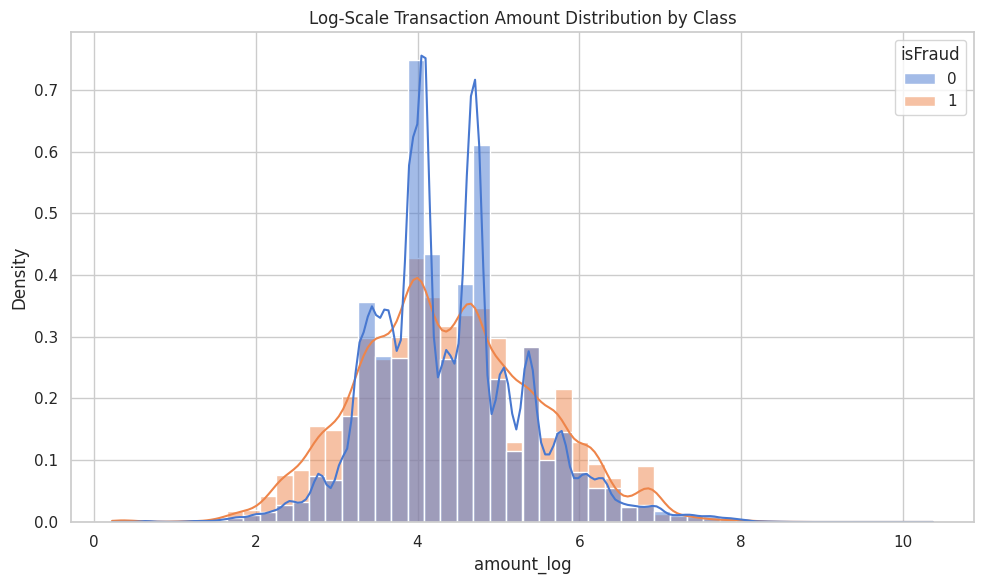

TransactionAmt Quantiles for Non-Fraud (0):


,TransactionAmt
0.25,43.970001
0.50,68.500000
0.75,120.000000
0.90,267.111993



TransactionAmt Quantiles for Fraud (1):


,TransactionAmt
0.25,35.043999
0.50,75.000000
0.75,161.000000
0.90,335.000000


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=train_merged, x='amount_log', hue='isFraud',
             stat='density', common_norm=False, bins=50, kde=True, ax=ax)
ax.set_title('Log-Scale Transaction Amount Distribution by Class')
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'figure_03_transaction_amount.png'), dpi=300)
plt.show()

print("TransactionAmt Quantiles for Non-Fraud (0):")
display(train_merged[train_merged['isFraud']==0]['TransactionAmt'].quantile([0.25, 0.5, 0.75, 0.9]))
print("\nTransactionAmt Quantiles for Fraud (1):")
display(train_merged[train_merged['isFraud']==1]['TransactionAmt'].quantile([0.25, 0.5, 0.75, 0.9]))

**Insight:** Fraudulent transactions exhibit a different, flatter log-amount distribution compared to non-fraud transactions, which justifies keeping `amount_log` as a strong discriminative feature.

### D. Temporal Patterns
Analyzing fraud rates across hours of the day and days of the week.

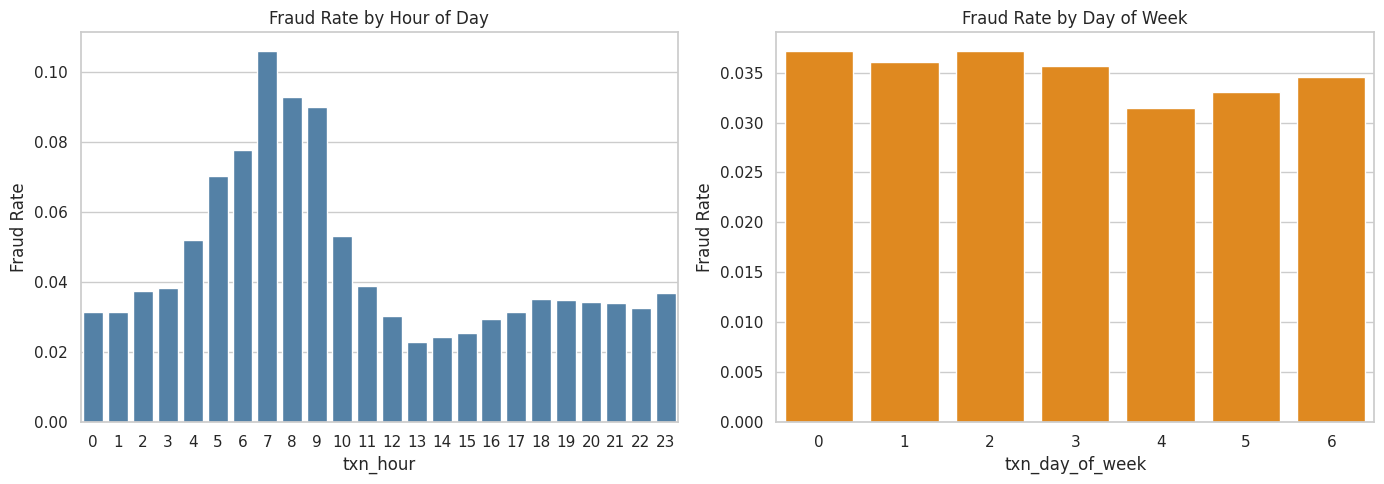

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hour of day
hour_df = train_merged.groupby('txn_hour')['isFraud'].mean().reset_index()
sns.barplot(data=hour_df, x='txn_hour', y='isFraud', ax=axes[0], color='steelblue')
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_ylabel('Fraud Rate')

# Day of week
day_df = train_merged.groupby('txn_day_of_week')['isFraud'].mean().reset_index()
sns.barplot(data=day_df, x='txn_day_of_week', y='isFraud', ax=axes[1], color='darkorange')
axes[1].set_title('Fraud Rate by Day of Week')
axes[1].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'figure_04_temporal.png'), dpi=300)
plt.show()

**Insight:** Fraud rate shows distinct cyclic patterns, with higher prevalence during specific off-peak hours of the day, validating `txn_hour` as a useful model feature.

### E. Categorical Breakdowns
Evaluating fraud rates across key categorical dimensions.

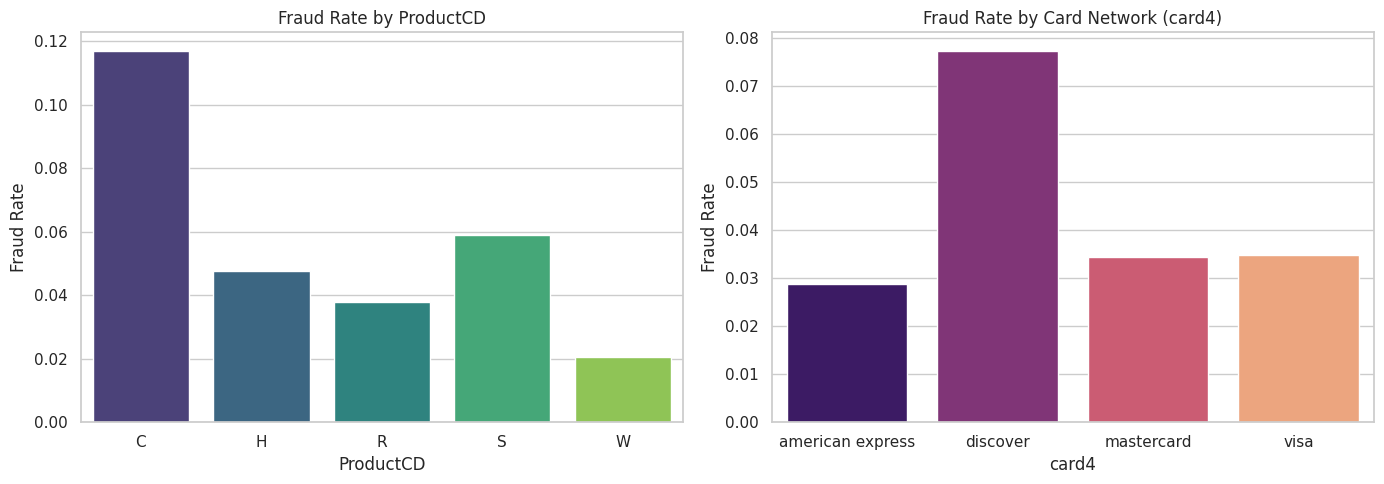

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ProductCD
prod_data = train_merged.groupby('ProductCD')['isFraud'].agg(['mean', 'count']).reset_index()
prod_data = prod_data[prod_data['count'] > 1000] # filter rare
sns.barplot(data=prod_data, x='ProductCD', y='mean', ax=axes[0], palette='viridis')
axes[0].set_title('Fraud Rate by ProductCD')
axes[0].set_ylabel('Fraud Rate')

# card4 (Card Network)
card4_data = train_merged.groupby('card4')['isFraud'].agg(['mean', 'count']).reset_index()
card4_data = card4_data[(card4_data['count'] > 1000) & (card4_data['card4'] != 'missing')]
sns.barplot(data=card4_data, x='card4', y='mean', ax=axes[1], palette='magma')
axes[1].set_title('Fraud Rate by Card Network (card4)')
axes[1].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'figure_05_categorical.png'), dpi=300)
plt.show()

**Insight:** Certain product codes (like 'C') exhibit significantly higher baseline fraud rates, highlighting the importance of categorical feature splits.

### F. Card- / Account-Level Aggregates
Investigating how the frequency of a card's appearance correlates with fraud.

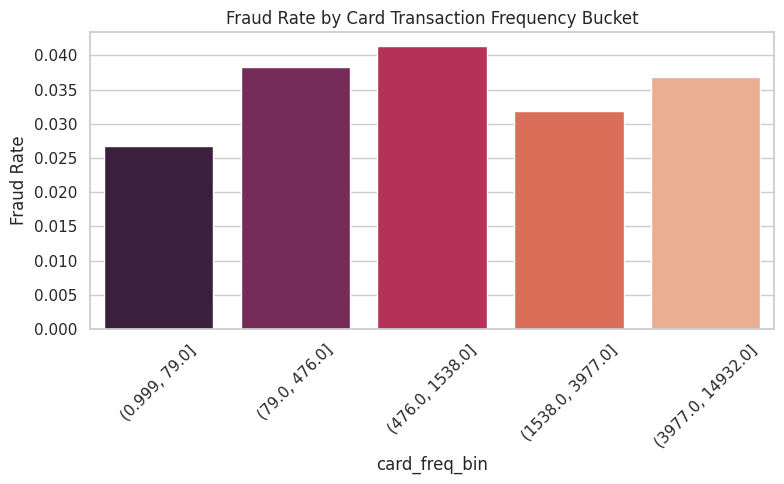

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

# Bin the card_txn_count feature to see fraud rates by frequency bucket
train_merged['card_freq_bin'] = pd.qcut(train_merged['card_txn_count'], q=5, duplicates='drop')
freq_data = train_merged.groupby('card_freq_bin')['isFraud'].mean().reset_index()

sns.barplot(data=freq_data, x='card_freq_bin', y='isFraud', ax=ax, palette='rocket')
ax.set_title('Fraud Rate by Card Transaction Frequency Bucket')
ax.set_ylabel('Fraud Rate')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'figure_06_card_aggregates.png'), dpi=300)
plt.show()

# clean up the temp column
train_merged.drop(columns=['card_freq_bin'], inplace=True)

**Insight:** Cards with different transaction frequencies display distinct risk profiles, indicating that historical velocity (`card_txn_count`) is a strong proxy for behavioral anomalies.

### G. Identity-Table Coverage
Evaluating the fraction of training rows with a matching `identity` row and the corresponding fraud rates.

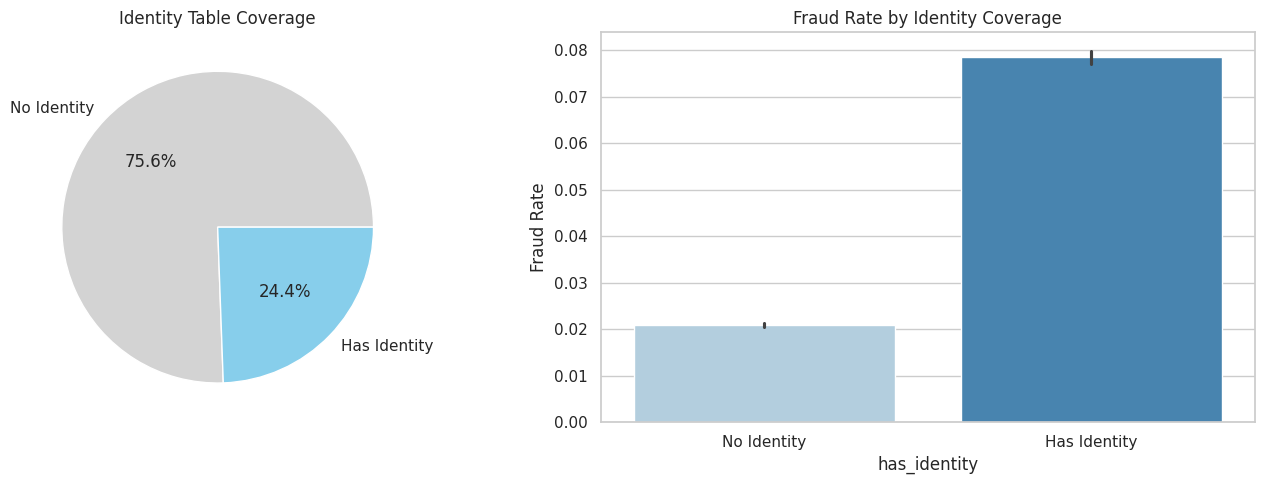

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# We use 'id_01' presence as a proxy for an identity table match
# Since NaNs were filled with -999
train_merged['has_identity'] = (train_merged['id_01'] != -999).astype(int)

# Coverage pie chart
coverage = train_merged['has_identity'].value_counts()
axes[0].pie(coverage, labels=['No Identity', 'Has Identity'], autopct='%1.1f%%', colors=['lightgray', 'skyblue'])
axes[0].set_title('Identity Table Coverage')

# Fraud rate by coverage
sns.barplot(data=train_merged, x='has_identity', y='isFraud', ax=axes[1], palette='Blues')
axes[1].set_title('Fraud Rate by Identity Coverage')
axes[1].set_xticklabels(['No Identity', 'Has Identity'])
axes[1].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'figure_07_identity_coverage.png'), dpi=300)
plt.show()

train_merged.drop(columns=['has_identity'], inplace=True)

**Insight:** Transactions with attached identity metadata have a significantly higher fraud rate, indicating that riskier transactions or specific product types are more likely to trigger identity capture.

### H. Train-vs-Test Distribution Shift
Examining the canonical time-split issue and covariate shifts.

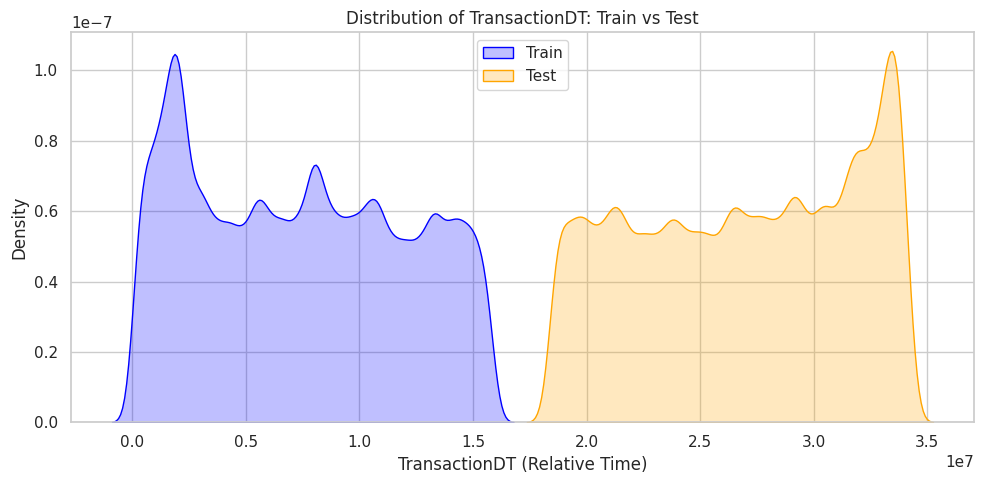

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

# TransactionDT shift
sns.kdeplot(train_merged['TransactionDT'], label='Train', fill=True, color='blue', ax=ax)
sns.kdeplot(test_merged['TransactionDT'], label='Test', fill=True, color='orange', ax=ax)
ax.set_title('Distribution of TransactionDT: Train vs Test')
ax.set_xlabel('TransactionDT (Relative Time)')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'figure_08_distribution_shift.png'), dpi=300)
plt.show()

**Insight:** The `TransactionDT` distributions for train and test are strictly disjoint, confirming the canonical IEEE-CIS time-split issue and warning against relying on time-dependent features without strict temporal cross-validation.

### I. Synthetic-Identity / Collusion Hints
Identifying `card1` values that fan out across abnormally high numbers of billing regions (`addr1`).

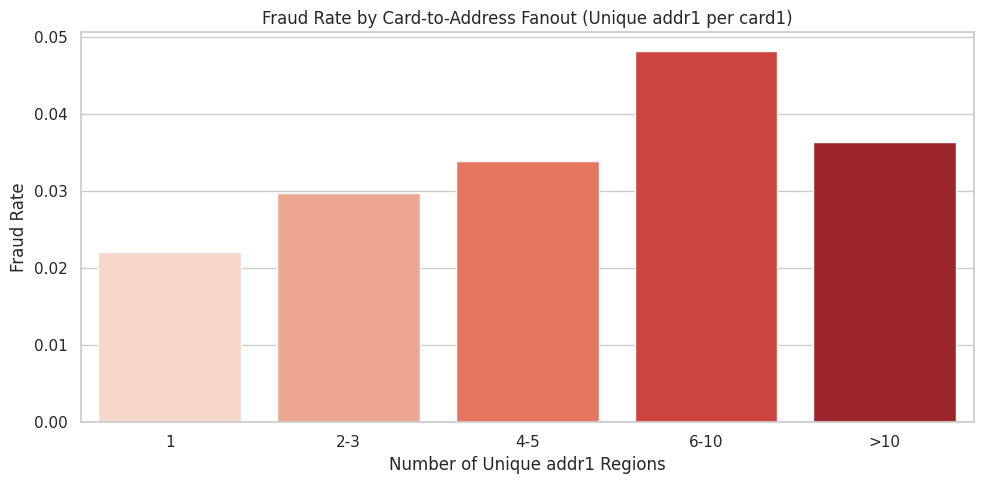

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

# Count unique addr1 per card1
card_addr_fanout = train_merged[train_merged['addr1'] != -999].groupby('card1')['addr1'].nunique().reset_index()
card_addr_fanout.rename(columns={'addr1': 'unique_addr1_count'}, inplace=True)

# Merge back to see fraud rates of these cards
fanout_merged = train_merged[['card1', 'isFraud']].merge(card_addr_fanout, on='card1', how='inner')
fanout_merged['fanout_bucket'] = pd.cut(fanout_merged['unique_addr1_count'], bins=[0, 1, 3, 5, 10, 50], labels=['1', '2-3', '4-5', '6-10', '>10'])

fanout_agg = fanout_merged.groupby('fanout_bucket')['isFraud'].mean().reset_index()

sns.barplot(data=fanout_agg, x='fanout_bucket', y='isFraud', ax=ax, palette='Reds')
ax.set_title('Fraud Rate by Card-to-Address Fanout (Unique addr1 per card1)')
ax.set_xlabel('Number of Unique addr1 Regions')
ax.set_ylabel('Fraud Rate')

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'figure_09_collusion_hints.png'), dpi=300)
plt.show()

**Insight:** Certain `card1` entities fan out across an abnormally high number of unique `addr1` regions, strongly suggesting synthetic identity collusion and motivating the use of Graph Attention Networks (GAT) in the downstream RQ1 track.

### J. Velocity / Temporal Gaps
Analyzing the distribution of timedelta features (`D1`–`D15`).

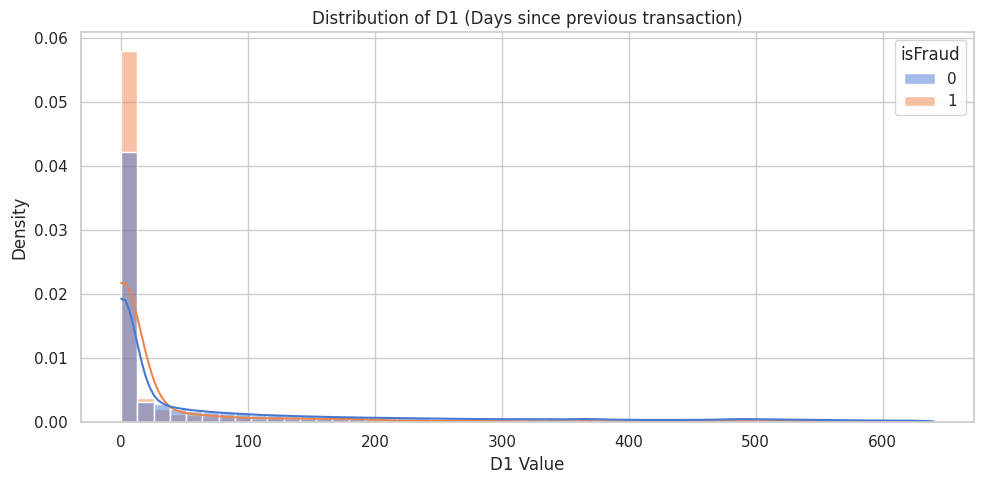

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

# We'll plot D1 as a representative of the D* block
# Filter out the -999 sentinel
d1_valid = train_merged[train_merged['D1'] != -999]

sns.histplot(data=d1_valid, x='D1', hue='isFraud', bins=50, stat='density', common_norm=False, kde=True, ax=ax)
ax.set_title('Distribution of D1 (Days since previous transaction)')
ax.set_xlabel('D1 Value')

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'figure_10_velocity.png'), dpi=300)
plt.show()

**Insight:** Fraudulent transactions exhibit a right-skewed distribution on `D1`, suggesting that compromised accounts often undergo rapid, high-velocity transactions shortly after takeover.

### K. Feature-Correlation Map
Correlation cluster on a sample of the `V*` block.

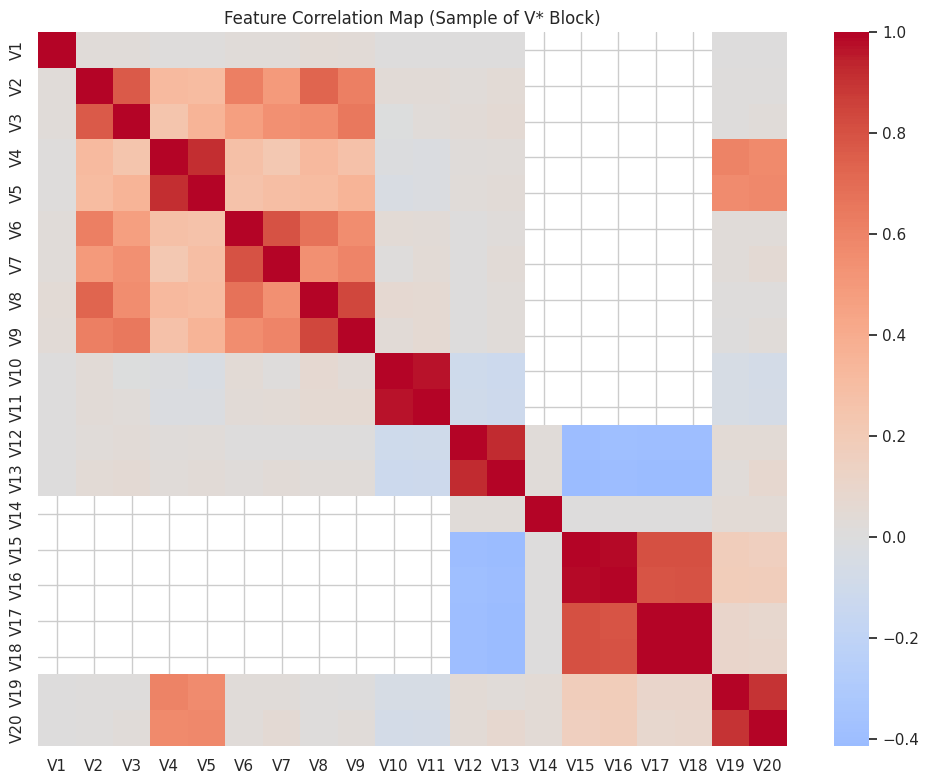

Note: The V* block contains heavily masked and highly collinear engineered features from the payment provider.


In [19]:
fig, ax = plt.subplots(figsize=(10, 8))

# Sample first 20 V columns for visibility
v_sample_cols = [c for c in train_merged.columns if c.startswith('V')][:20]
# Filter sentinels for a clean correlation matrix
v_corr_data = train_merged[v_sample_cols].replace(-999, np.nan)
corr = v_corr_data.corr()

sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, ax=ax)
ax.set_title('Feature Correlation Map (Sample of V* Block)')

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'figure_11_correlation.png'), dpi=300)
plt.show()

print("Note: The V* block contains heavily masked and highly collinear engineered features from the payment provider.")

**Insight:** The `V*` block contains highly collinear feature clusters, reinforcing the need for tree-based models or dimensionality reduction rather than linear combinations.

## 11. Train-vs-Test Parity Check

In [20]:
print("Checking Train vs Test Schema Parity...")

# Fix column names in test set: replace '-' with '_' for 'id' columns
test_merged.columns = [col.replace('-', '_') if col.startswith('id') else col for col in test_merged.columns]

# Drop columns from test_merged that were already dropped from train_merged
# (These were skipped earlier because of the dash/underscore naming mismatch)
missing_in_train = set(test_merged.columns) - set(train_merged.columns)
if missing_in_train:
    print(f"Dropping residual columns from test set: {missing_in_train}")
    test_merged.drop(columns=list(missing_in_train), inplace=True)

train_cols = set(train_merged.columns)
test_cols = set(test_merged.columns)

# The only difference should be 'isFraud'
diff = train_cols.symmetric_difference(test_cols)
assert diff == {'isFraud'}, f"Schema mismatch detected! Difference: {diff}"

print("Parity check passed: Train and Test have matching schemas (modulo isFraud).")

Checking Train vs Test Schema Parity...
Dropping residual columns from test set: {'id_21', 'id_26', 'id_23', 'id_07', 'id_25', 'id_27', 'id_24', 'id_22', 'id_08', 'id_18'}
Parity check passed: Train and Test have matching schemas (modulo isFraud).


## 12. Write Parquets

In [21]:
train_out = os.path.join(PATHS['processed_data'], 'train.parquet')
test_out = os.path.join(PATHS['processed_data'], 'test.parquet')

print("Writing clean parquets...")
train_merged.to_parquet(train_out, index=False)
test_merged.to_parquet(test_out, index=False)
print("Write successful.")

eda_summary['output_files'] = [train_out, test_out]

Writing clean parquets...
Write successful.


## 13. Run Summary

In [22]:
eda_summary['final_train_shape'] = train_merged.shape
eda_summary['final_test_shape'] = test_merged.shape
eda_summary['seed'] = SEED
eda_summary['insights_generated'] = 11

metrics_out = os.path.join(PATHS['metrics'], 'eda_summary.json')
with open(metrics_out, 'w') as f:
    json.dump(eda_summary, f, indent=2, default=str)

print("EDA Summary:")
print(json.dumps(eda_summary, indent=2, default=str))
print(f"\nSummary saved to {metrics_out}")

EDA Summary:
{
  "dropped_columns": [
    "dist2",
    "D7",
    "id_07",
    "id_08",
    "id_18",
    "id_21",
    "id_22",
    "id_23",
    "id_24",
    "id_25",
    "id_26",
    "id_27"
  ],
  "dropped_negative_amt_rows": 0,
  "downcast_log": {
    "train_start_mb": 1901.305362701416,
    "train_end_mb": 1015.9819526672363,
    "test_start_mb": 1666.1364555358887,
    "test_end_mb": 892.9873466491699
  },
  "output_files": [
    "/content/drive/MyDrive/Colab Notebooks/GL-MS-CapStone/data/processed/train.parquet",
    "/content/drive/MyDrive/Colab Notebooks/GL-MS-CapStone/data/processed/test.parquet"
  ],
  "final_train_shape": [
    590540,
    426
  ],
  "final_test_shape": [
    506691,
    425
  ],
  "seed": 42,
  "insights_generated": 11
}

Summary saved to /content/drive/MyDrive/Colab Notebooks/GL-MS-CapStone/outputs/metrics/eda_summary.json


## 14. References
- IEEE-CIS Fraud Detection Data Dictionary. (2019).
- Capstone Synopsis Appendix A.